# Bottleneck & Pressure Analysis

## Objective

Identify periods of increased operational pressure within the UAC care pipeline by comparing incoming and outgoing activity at the CBP and HHS stages.

## Business Questions

- Where does operational pressure accumulate in the care pipeline?
- Are transfers keeping pace with apprehensions?
- Are discharges keeping pace with transfers into HHS care?
- Which reporting periods show unusually high pressure?
- Are pressure patterns persistent or isolated?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/uac_eda.csv")

df["date"] = pd.to_datetime(df["date"])

df.head()

,date,apprehended,cbp_custody,transferred,hhs_care,discharged,month,year,cbp_net_pressure,hhs_net_pressure,day_of_week
0,2023-01-12,33.0,53.0,34.0,6566,436.0,2023-01,2023,-1.0,-402.0,Thursday
1,2023-01-22,32.0,49.0,39.0,7122,227.0,2023-01,2023,-7.0,-188.0,Sunday
2,2023-01-23,32.0,50.0,39.0,7280,181.0,2023-01,2023,-7.0,-142.0,Monday
3,2023-01-24,47.0,42.0,47.0,7433,175.0,2023-01,2023,0.0,-128.0,Tuesday
4,2023-01-25,20.0,22.0,41.0,7538,180.0,2023-01,2023,-21.0,-139.0,Wednesday


## 6.1 CBP Net Pressure

### Business Question

Are children entering CBP custody at a higher rate than they are being transferred out?

### Description

CBP Net Pressure is calculated as apprehensions minus transfers.

A positive value indicates that recorded apprehension activity exceeded recorded transfers during a reporting period, while a negative value indicates that transfers exceeded apprehensions.

This measure is used as an indicator of operational pressure rather than a direct measurement of individual backlog.

In [2]:
df["cbp_net_pressure"] = (
    df["apprehended"] -
    df["transferred"]
)

df[
    [
        "date",
        "apprehended",
        "transferred",
        "cbp_net_pressure"
    ]
].head()

,date,apprehended,transferred,cbp_net_pressure
0,2023-01-12,33.0,34.0,-1.0
1,2023-01-22,32.0,39.0,-7.0
2,2023-01-23,32.0,39.0,-7.0
3,2023-01-24,47.0,47.0,0.0
4,2023-01-25,20.0,41.0,-21.0


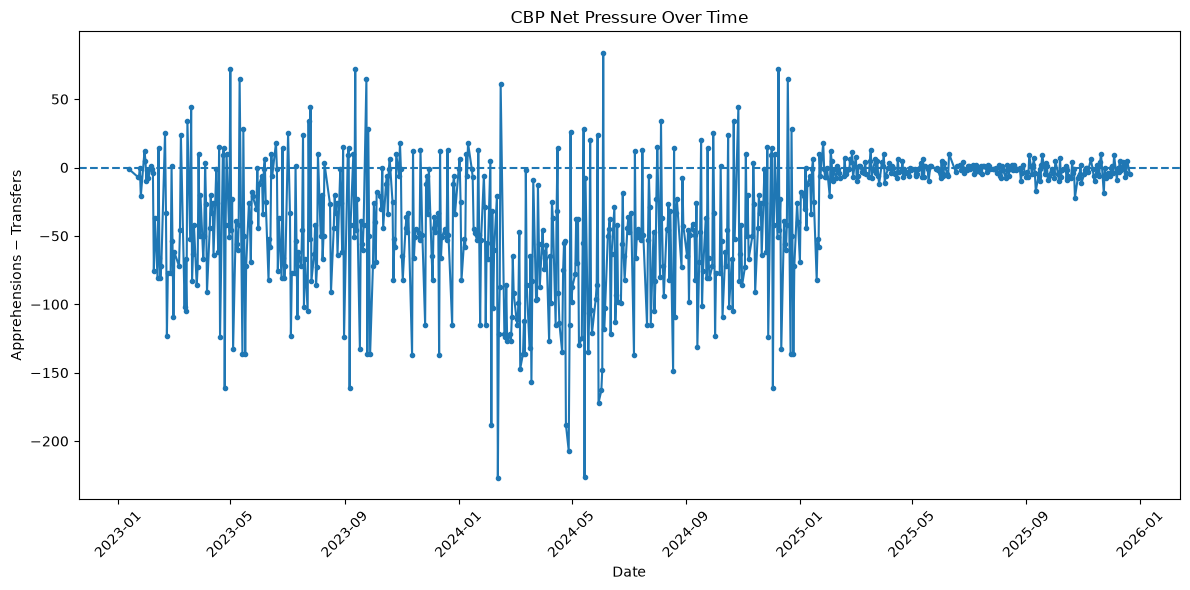

In [3]:
plt.figure(figsize=(12, 6))

plt.plot(
    df["date"],
    df["cbp_net_pressure"],
    marker="o",
    markersize=3
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title("CBP Net Pressure Over Time")
plt.xlabel("Date")
plt.ylabel("Apprehensions − Transfers")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Figure 1: CBP Net Pressure Over Time

### Key Finding

CBP net pressure varies across reporting periods, with periods where apprehension activity exceeds transfer activity and periods where transfers exceed apprehensions.

### Business Implication

Periods of sustained positive CBP net pressure may indicate increased operational pressure and can be examined alongside custody levels and transfer efficiency.

## 6.2 HHS Net Pressure

### Business Question

Are discharges keeping pace with transfers into HHS care?

### Description

HHS Net Pressure is calculated as transfers minus discharges.

A positive value indicates that recorded transfers into HHS care exceeded recorded discharges during a reporting period.

This provides an aggregate indicator of pressure on the HHS stage of the pipeline.

In [4]:
df["hhs_net_pressure"] = (
    df["transferred"] -
    df["discharged"]
)

df[
    [
        "date",
        "transferred",
        "discharged",
        "hhs_net_pressure"
    ]
].head()

,date,transferred,discharged,hhs_net_pressure
0,2023-01-12,34.0,436.0,-402.0
1,2023-01-22,39.0,227.0,-188.0
2,2023-01-23,39.0,181.0,-142.0
3,2023-01-24,47.0,175.0,-128.0
4,2023-01-25,41.0,180.0,-139.0


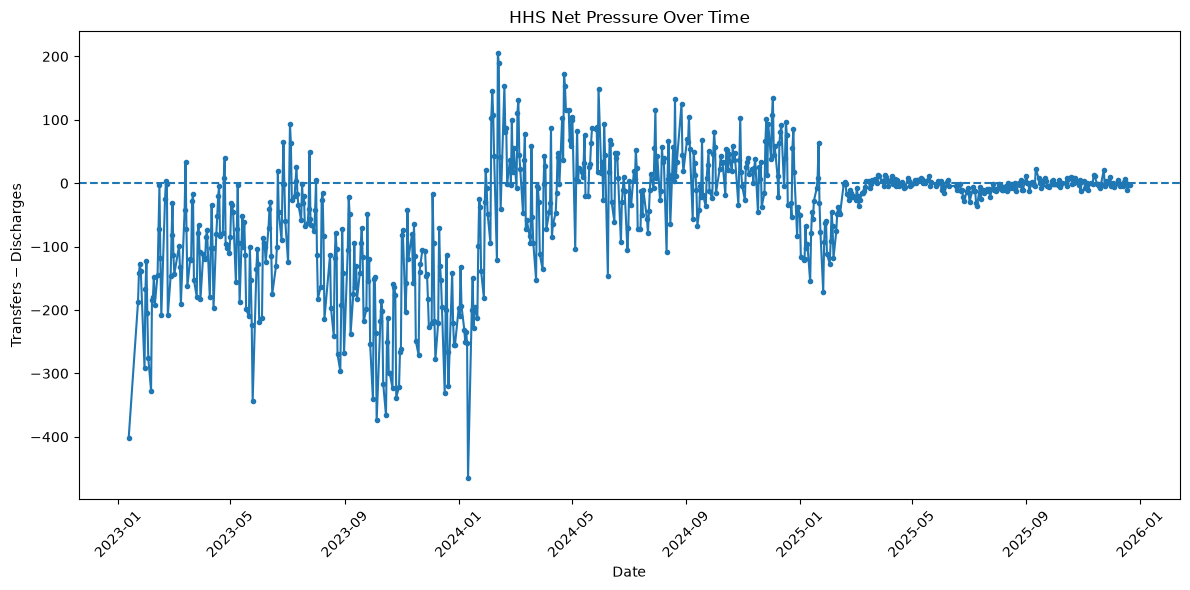

In [5]:
plt.figure(figsize=(12, 6))

plt.plot(
    df["date"],
    df["hhs_net_pressure"],
    marker="o",
    markersize=3
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title("HHS Net Pressure Over Time")
plt.xlabel("Date")
plt.ylabel("Transfers − Discharges")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Figure 2: HHS Net Pressure Over Time

### Key Finding

HHS net pressure fluctuates across reporting periods, showing periods where transfers into HHS care exceed recorded discharges.

### Business Implication

Sustained positive HHS net pressure can be used to identify periods requiring closer examination of discharge activity and HHS care capacity.

## 6.3 Cumulative Pressure

### Business Question

Are periods of operational pressure isolated, or do they persist over time?

### Description

Cumulative pressure aggregates the period-level pressure measures across the observation period.

This helps identify whether positive pressure repeatedly accumulates over multiple reporting periods.

In [6]:
df["cumulative_cbp_pressure"] = (
    df["cbp_net_pressure"].cumsum()
)

df["cumulative_hhs_pressure"] = (
    df["hhs_net_pressure"].cumsum()
)

df[
    [
        "date",
        "cumulative_cbp_pressure",
        "cumulative_hhs_pressure"
    ]
].tail()

,date,cumulative_cbp_pressure,cumulative_hhs_pressure
715,2025-12-15,-25293.0,-32206.0
716,2025-12-16,-25300.0,-32200.0
717,2025-12-17,-25304.0,-32199.0
718,2025-12-18,-25299.0,-32209.0
719,2025-12-21,-25304.0,-32212.0


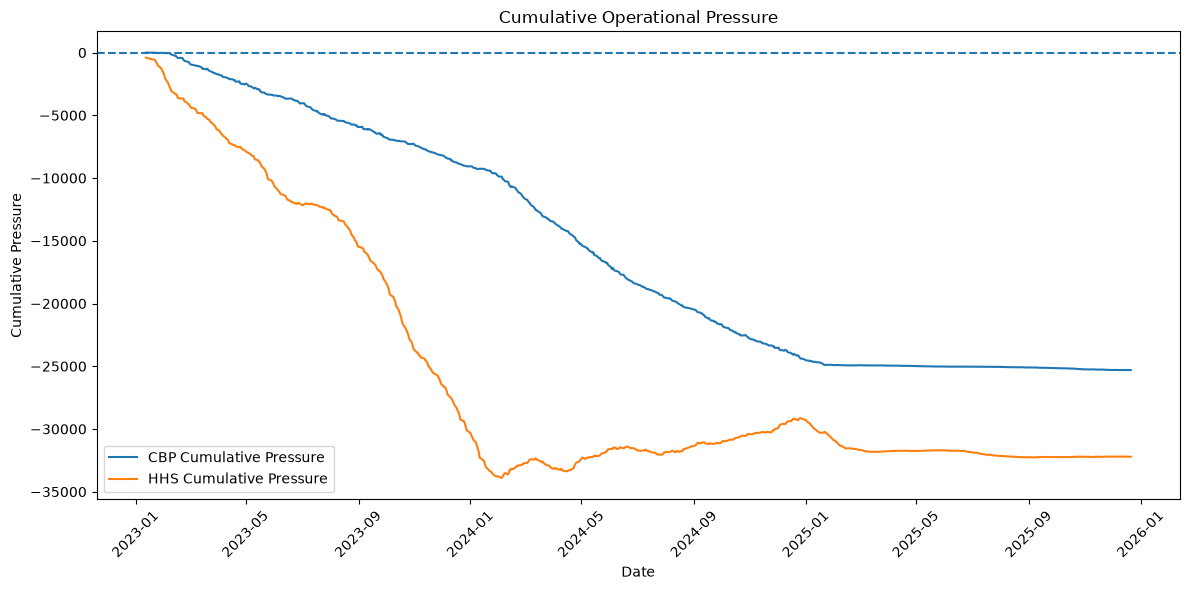

In [7]:
plt.figure(figsize=(12, 6))

plt.plot(
    df["date"],
    df["cumulative_cbp_pressure"],
    label="CBP Cumulative Pressure"
)

plt.plot(
    df["date"],
    df["cumulative_hhs_pressure"],
    label="HHS Cumulative Pressure"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title("Cumulative Operational Pressure")
plt.xlabel("Date")
plt.ylabel("Cumulative Pressure")
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Figure 3: Cumulative Operational Pressure

### Key Finding

Cumulative pressure reveals whether positive or negative period-level differences persist across the observation period.

### Business Implication

Persistent pressure patterns may be more operationally important than isolated spikes and can help prioritize periods for further investigation.

## 6.4 Pressure Distribution

### Business Question

What is the typical range of CBP and HHS operational pressure?

### Description

Distribution analysis compares the variability of CBP and HHS net pressure across reporting periods.

The analysis helps identify the normal range of pressure and observations that differ substantially from typical values.

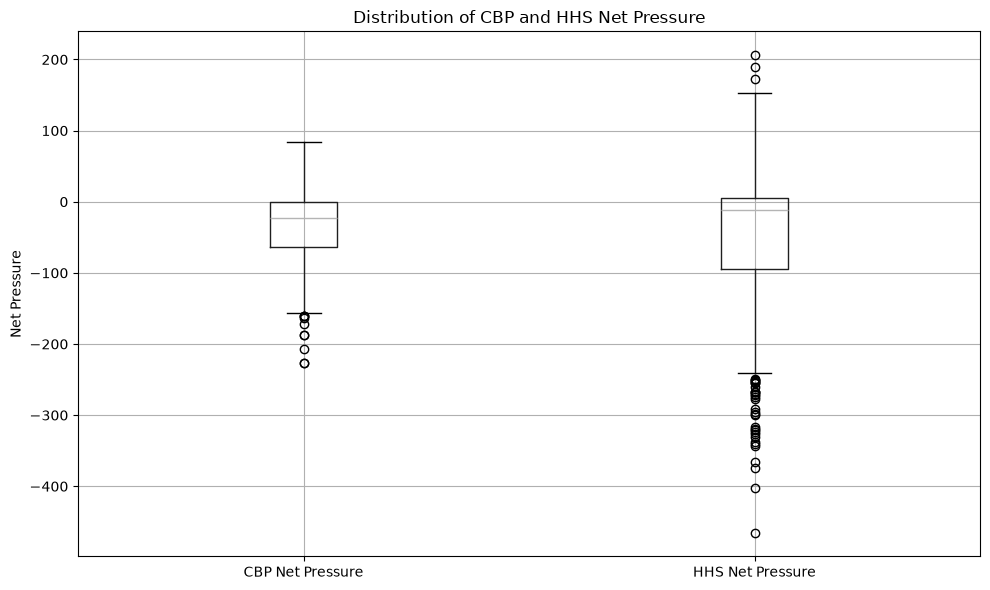

In [8]:
pressure_data = df[
    [
        "cbp_net_pressure",
        "hhs_net_pressure"
    ]
]

plt.figure(figsize=(10, 6))

pressure_data.boxplot()

plt.title("Distribution of CBP and HHS Net Pressure")
plt.ylabel("Net Pressure")

plt.xticks(
    [1, 2],
    ["CBP Net Pressure", "HHS Net Pressure"]
)

plt.tight_layout()
plt.show()

### Figure 4: Distribution of CBP and HHS Net Pressure

### Key Finding

The distributions show the typical range and variability of operational pressure at the CBP and HHS stages.

### Business Implication

Greater variability in pressure indicates that operational conditions are not uniform across reporting periods and may require closer monitoring.

## 6.5 High-Pressure Periods

### Business Question

Which reporting periods experienced the highest operational pressure?

### Description

The highest CBP and HHS net-pressure observations are identified to provide specific periods for further investigation.

In [9]:
top_cbp_pressure = (
    df.nlargest(10, "cbp_net_pressure")
    [
        [
            "date",
            "apprehended",
            "transferred",
            "cbp_net_pressure"
        ]
    ]
)

top_hhs_pressure = (
    df.nlargest(10, "hhs_net_pressure")
    [
        [
            "date",
            "transferred",
            "discharged",
            "hhs_net_pressure"
        ]
    ]
)

print("Highest CBP Pressure Periods")
display(top_cbp_pressure)

print("Highest HHS Pressure Periods")
display(top_hhs_pressure)

Highest CBP Pressure Periods


,date,apprehended,transferred,cbp_net_pressure
338,2024-06-04,260.0,176.0,84.0
67,2023-05-01,224.0,152.0,72.0
156,2023-09-12,224.0,152.0,72.0
465,2024-12-09,224.0,152.0,72.0
75,2023-05-11,269.0,204.0,65.0
164,2023-09-24,269.0,204.0,65.0
473,2024-12-19,269.0,204.0,65.0
262,2024-02-15,333.0,272.0,61.0
37,2023-03-20,202.0,158.0,44.0
126,2023-07-26,202.0,158.0,44.0


Highest HHS Pressure Periods


,date,transferred,discharged,hhs_net_pressure
259,2024-02-12,440.0,234.0,206.0
260,2024-02-13,349.0,160.0,189.0
309,2024-04-23,307.0,134.0,173.0
263,2024-02-19,371.0,218.0,153.0
310,2024-04-24,307.0,154.0,153.0
335,2024-05-30,339.0,190.0,149.0
255,2024-02-06,323.0,178.0,145.0
461,2024-12-03,242.0,107.0,135.0
391,2024-08-20,245.0,112.0,133.0
274,2024-03-05,345.0,214.0,131.0


### Key Finding

The high-pressure analysis identifies specific reporting periods with the largest positive differences between incoming and outgoing activity.

### Business Implication

These periods can be used as investigation points to understand when operational pressure was greatest and whether similar patterns occurred elsewhere in the pipeline.

## 6.6 Pressure Threshold Analysis

### Business Question

Which reporting periods should be flagged for unusually high operational pressure?

### Description

A threshold-based approach identifies observations where net pressure is substantially higher than the typical reporting-period pressure.

The threshold is based on the 75th percentile of each pressure measure.

In [10]:
cbp_threshold = df["cbp_net_pressure"].quantile(0.75)
hhs_threshold = df["hhs_net_pressure"].quantile(0.75)

df["cbp_high_pressure"] = (
    df["cbp_net_pressure"] >= cbp_threshold
)

df["hhs_high_pressure"] = (
    df["hhs_net_pressure"] >= hhs_threshold
)

print(f"CBP High-Pressure Threshold: {cbp_threshold:.2f}")
print(f"HHS High-Pressure Threshold: {hhs_threshold:.2f}")

CBP High-Pressure Threshold: -1.00
HHS High-Pressure Threshold: 5.25


In [11]:
high_pressure_periods = df[
    (df["cbp_high_pressure"]) |
    (df["hhs_high_pressure"])
][
    [
        "date",
        "cbp_net_pressure",
        "hhs_net_pressure",
        "cbp_high_pressure",
        "hhs_high_pressure"
    ]
]

display(high_pressure_periods)

,date,cbp_net_pressure,hhs_net_pressure,cbp_high_pressure,hhs_high_pressure
0,2023-01-12,-1.0,-402.0,True,False
3,2023-01-24,0.0,-128.0,True,False
5,2023-01-29,12.0,-292.0,True,False
6,2023-01-30,5.0,-167.0,True,False
10,2023-02-05,1.0,-327.0,True,False
...,...,...,...,...,...
712,2025-12-10,5.0,-4.0,True,False
714,2025-12-14,4.0,-4.0,True,False
715,2025-12-15,2.0,2.0,True,False
716,2025-12-16,-7.0,6.0,False,True


### Key Finding

The threshold analysis identifies reporting periods where operational pressure is relatively high compared with the broader observation period.

### Business Implication

These threshold flags can support the alert logic used in the Streamlit dashboard and help stakeholders focus attention on higher-pressure periods.

## 6.7 Bottleneck Comparison

### Business Question

Which stage of the pipeline shows greater operational pressure?

### Description

CBP and HHS pressure are compared using standardized pressure measures.

Because the absolute scales of CBP and HHS activity differ, direct comparison of raw pressure values can be misleading. Standardized pressure is therefore used to compare relative deviations from each stage's typical pressure.

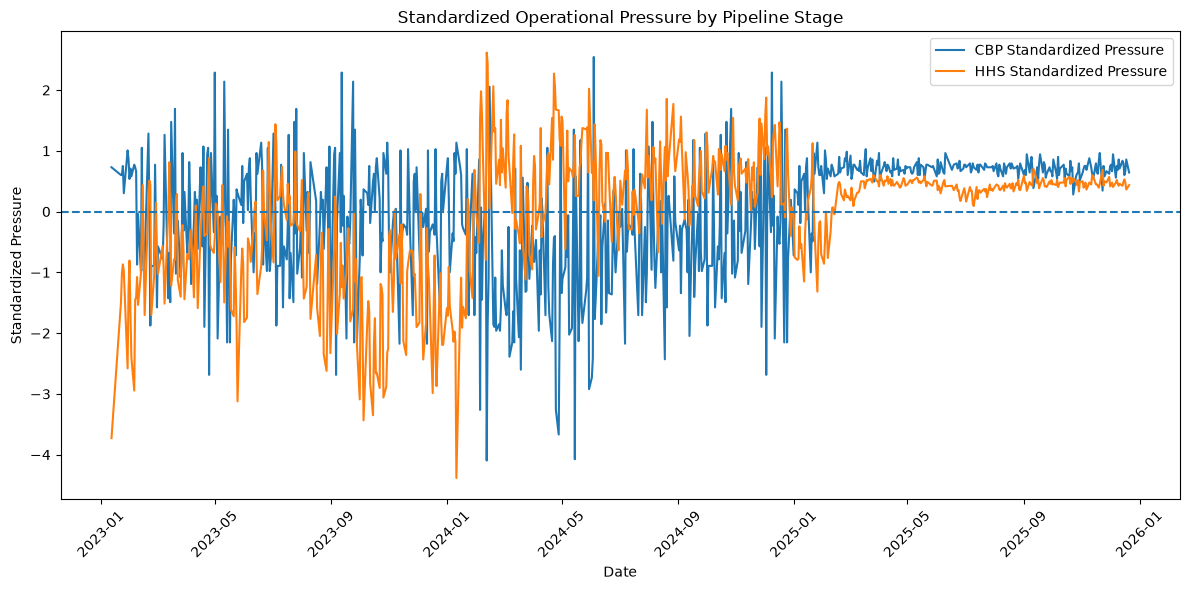

In [12]:
df["cbp_pressure_z"] = (
    (df["cbp_net_pressure"] - df["cbp_net_pressure"].mean()) /
    df["cbp_net_pressure"].std()
)

df["hhs_pressure_z"] = (
    (df["hhs_net_pressure"] - df["hhs_net_pressure"].mean()) /
    df["hhs_net_pressure"].std()
)

plt.figure(figsize=(12, 6))

plt.plot(
    df["date"],
    df["cbp_pressure_z"],
    label="CBP Standardized Pressure"
)

plt.plot(
    df["date"],
    df["hhs_pressure_z"],
    label="HHS Standardized Pressure"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title("Standardized Operational Pressure by Pipeline Stage")
plt.xlabel("Date")
plt.ylabel("Standardized Pressure")
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Figure 5: Standardized Operational Pressure by Pipeline Stage

### Key Finding

Standardized pressure allows CBP and HHS operational pressure to be compared relative to their own typical reporting-period conditions.

### Business Implication

The comparison helps identify which pipeline stage is experiencing relatively greater pressure during different periods.

## 6.8 Bottleneck KPI Summary

### Business Question

What are the main pressure indicators identified in the analysis?

### Description

The KPI summary consolidates the major pressure indicators developed during this phase.

In [13]:
bottleneck_kpis = pd.DataFrame({
    "KPI": [
        "Average CBP Net Pressure",
        "Average HHS Net Pressure",
        "Maximum CBP Net Pressure",
        "Maximum HHS Net Pressure",
        "CBP High-Pressure Periods",
        "HHS High-Pressure Periods"
    ],
    "Value": [
        df["cbp_net_pressure"].mean(),
        df["hhs_net_pressure"].mean(),
        df["cbp_net_pressure"].max(),
        df["hhs_net_pressure"].max(),
        df["cbp_high_pressure"].sum(),
        df["hhs_high_pressure"].sum()
    ]
})

bottleneck_kpis

,KPI,Value
0,Average CBP Net Pressure,-35.144444
1,Average HHS Net Pressure,-44.738889
2,Maximum CBP Net Pressure,84.000000
3,Maximum HHS Net Pressure,206.000000
4,CBP High-Pressure Periods,203.000000
5,HHS High-Pressure Periods,180.000000


## Executive Summary

### Key Findings

- CBP net pressure varies across reporting periods based on the relationship between apprehensions and transfers.
- HHS net pressure varies according to the relationship between transfers and discharges.
- Cumulative pressure helps distinguish persistent pressure patterns from isolated reporting-period changes.
- High-pressure periods identify specific observations that warrant further operational investigation.
- Threshold analysis provides a practical method for flagging unusually high-pressure periods.
- Standardized pressure allows relative comparison between CBP and HHS despite differences in their operational scales.

### Conclusion

This analysis identifies potential pressure points within the UAC care pipeline using aggregate inflow and outflow measures.

The analysis does not directly measure individual waiting time or confirmed backlog duration. Instead, it provides operational pressure indicators that can be used to identify periods requiring further investigation.

These indicators provide the foundation for dashboard alerts, bottleneck monitoring, and stakeholder-focused reporting.